# Scoring de Risque Crédit — Fintech
### Prédiction de la probabilité de défaut de paiement client

**Contexte métier :** Dans une fintech proposant des services de paiement et de crédit (type FedaPay), l'octroi de crédit ou la gestion du risque client nécessite d'identifier en amont les profils à risque de défaut de paiement, afin d'ajuster les décisions (conditions, plafonds, vigilance) sans pénaliser les bons clients.

**Objectif :** Construire un modèle de Machine Learning capable d'estimer la probabilité de défaut d'un client à partir de ses données financières et comportementales (revenu, historique de paiement, score bureau externe, type de contrat, etc.), puis exposer les résultats dans un dashboard Power BI pour les équipes risque/métier.

**Démarche :**
1. Exploration des données (EDA)
2. Préparation et encodage des variables
3. Comparaison de 3 modèles (Régression Logistique, Random Forest, Gradient Boosting)
4. Évaluation (AUC, F1-score, matrice de confusion, importance des variables)
5. Export des prédictions pour un dashboard Power BI (segmentation par niveau de risque)

**Stack technique :** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Power BI


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, f1_score
)

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
np.random.seed(42)

# ── Racine du projet (fonctionne que le notebook soit lancé depuis notebook/ ou depuis la racine) ──
def _find_root():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / '.git').exists() or ((p / 'notebook').exists() and (p / 'data').exists()):
            return p
    return Path.cwd()

PROJECT_ROOT = _find_root()
DATA_DIR     = PROJECT_ROOT / "data"
FIGURES_DIR  = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)


## 1. Chargement et exploration des données (EDA)

Le dataset contient 8 000 profils clients avec leurs caractéristiques financières et comportementales. La variable cible `default` indique si le client a connu un défaut de paiement (1) ou non (0).

> **Note méthodologique :** ce jeu de données est généré de façon synthétique mais selon une logique métier réaliste (corrélations cohérentes avec la littérature du scoring crédit : taux d'endettement, historique d'incidents, score bureau externe, type de contrat), afin de permettre un projet complet et reproductible en dehors d'un cadre professionnel.


In [2]:
df = pd.read_csv(DATA_DIR / "credit_scoring_dataset.csv")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Taux de défaut global : {df['default'].mean():.2%}")
df.head()

Dimensions : 8000 lignes x 12 colonnes
Taux de défaut global : 19.62%


,age,revenu_mensuel,anciennete_compte_mois,nb_transactions_mois,montant_moyen_transaction,taux_endettement_pct,nb_incidents_paiement_12m,montant_credit_demande,type_contrat,score_bureau_externe,utilisation_carte_pct,default
0,39,1794.12,17,22,182.01,21.30,1,1365.28,CDI,667,11.59,0
1,33,1454.43,57,22,26.34,3.04,0,2652.98,CDI,685,46.45,0
2,41,1686.01,9,11,15.84,26.61,2,7846.02,CDD,715,56.76,0
3,49,2504.31,4,19,47.92,31.24,1,2039.95,Indépendant,560,12.25,0
4,32,3219.32,29,15,50.16,15.36,0,2501.82,CDD,499,54.23,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,34.835875,9.319941,18.00,28.0000,35.000,41.0000,72.00
revenu_mensuel,8000.0,2020.401884,939.332810,800.00,1356.8525,1828.320,2458.6125,13422.28
anciennete_compte_mois,8000.0,23.861500,23.844379,1.00,7.0000,17.000,33.0000,219.00
nb_transactions_mois,8000.0,17.848125,4.165090,4.00,15.0000,18.000,21.0000,33.00
montant_moyen_transaction,8000.0,45.570374,41.677975,5.00,19.5775,33.485,57.2875,600.00
taux_endettement_pct,8000.0,28.684423,15.958135,0.17,16.1000,26.570,39.1125,89.60
nb_incidents_paiement_12m,8000.0,0.388375,0.625970,0.00,0.0000,0.000,1.0000,4.00
montant_credit_demande,8000.0,4342.811139,2904.606059,500.00,2390.4775,3649.515,5430.1150,35751.76
score_bureau_externe,8000.0,648.072000,87.157315,324.00,589.0000,648.500,708.0000,850.00
utilisation_carte_pct,8000.0,40.248587,19.781870,0.40,24.9400,38.710,54.5825,97.43


### Matrice de corrélation

On observe les relations entre variables numériques et la variable cible.

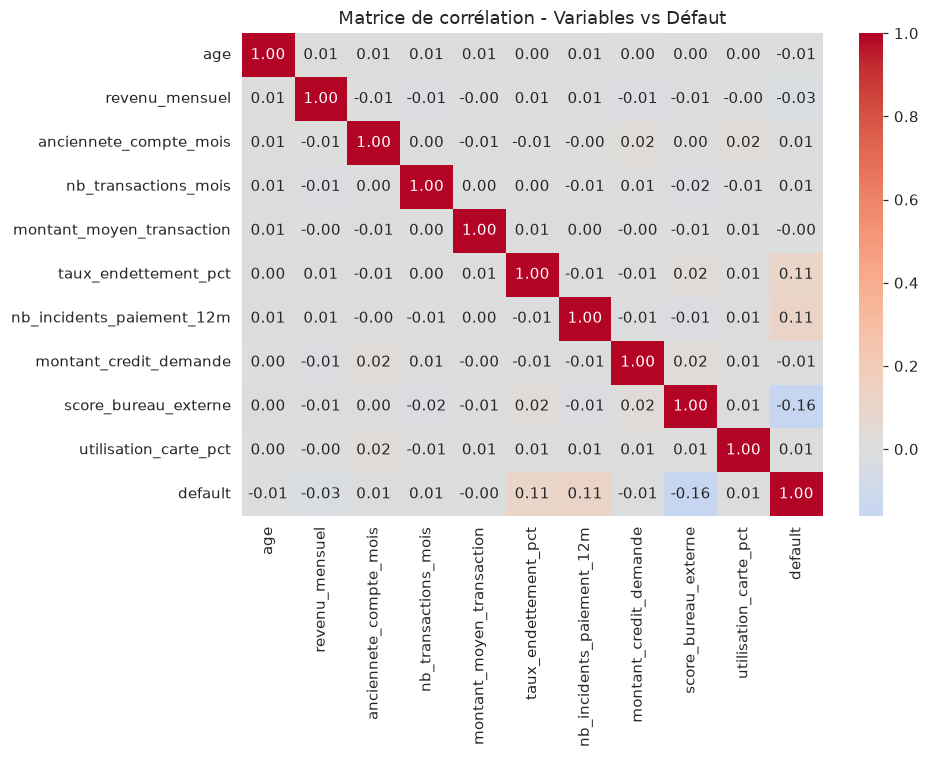

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("default")

plt.figure(figsize=(9, 7))
sns.heatmap(df[list(num_cols) + ["default"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Variables vs Défaut")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_correlation.png", bbox_inches="tight")
plt.show()

## 2. Préparation des données

- **Variables numériques** : standardisées (StandardScaler) pour les modèles sensibles à l'échelle (régression logistique)
- **Variable catégorielle** (`type_contrat`) : encodée en one-hot encoding
- **Split train/test** : 75% / 25%, stratifié sur la cible (pour conserver la proportion de défauts dans les deux échantillons)


In [5]:
X = df.drop(columns=["default"])
y = df["default"]

num_features = num_cols.tolist()
cat_features = ["type_contrat"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")

Train : 6000 clients | Test : 2000 clients


## 3. Comparaison de 3 modèles de classification

On compare trois approches de complexité croissante :
- **Régression Logistique** : modèle linéaire, interprétable, baseline solide en scoring crédit
- **Random Forest** : ensemble d'arbres, capte des interactions non-linéaires
- **Gradient Boosting** : boosting séquentiel, souvent performant sur ce type de données tabulaires

Chaque modèle utilise `class_weight="balanced"` (ou équivalent) pour compenser le déséquilibre des classes (les défauts sont minoritaires, ~19% des cas).


In [6]:
models = {
    "Regression Logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.08, random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()

    results.append({"Modele": name, "AUC (test)": round(auc, 4), "AUC (cross-val 5-fold)": round(cv_auc, 4), "F1-score": round(f1, 4)})
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Pas de defaut", "Defaut"]))


--- Regression Logistique ---
               precision    recall  f1-score   support

Pas de defaut       0.86      0.64      0.74      1608
       Defaut       0.28      0.56      0.37       392

     accuracy                           0.63      2000
    macro avg       0.57      0.60      0.55      2000
 weighted avg       0.74      0.63      0.66      2000




--- Random Forest ---
               precision    recall  f1-score   support

Pas de defaut       0.85      0.73      0.79      1608
       Defaut       0.31      0.48      0.38       392

     accuracy                           0.69      2000
    macro avg       0.58      0.61      0.58      2000
 weighted avg       0.75      0.69      0.71      2000




--- Gradient Boosting ---
               precision    recall  f1-score   support

Pas de defaut       0.81      0.99      0.89      1608
       Defaut       0.45      0.05      0.09       392

     accuracy                           0.80      2000
    macro avg       0.63      0.52      0.49      2000
 weighted avg       0.74      0.80      0.73      2000



In [7]:
results_df = pd.DataFrame(results).sort_values("AUC (test)", ascending=False)
results_df

,Modele,AUC (test),AUC (cross-val 5-fold),F1-score
0,Regression Logistique,0.6554,0.6818,0.3724
1,Random Forest,0.6474,0.6684,0.3762
2,Gradient Boosting,0.6430,0.6672,0.0917


### Baseline de référence

Pour interpréter l'AUC, il faut un **point de comparaison**. On construit une baseline naïve qui prédit toujours la classe majoritaire (« aucun défaut »). Par construction, son AUC est de 0,50 (équivalent au hasard pure), et son accuracy élevée est **trompeuse** puisqu'elle ne détecte aucun défaut. C'est cet écart entre la baseline et le modèle entraîné qui mesure la valeur réelle du modèle.

> Rappel : l'AUC est comprise entre 0 et 1. Un modèle parfait atteint 1,0. Un modèle aléatoire atteint 0,5.


In [8]:
# Baseline naïve : prédire toujours la classe majoritaire (jamais de défaut détecté)
_bl_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent")),
])
_bl_pipe.fit(X_train, y_train)

_bl_proba  = _bl_pipe.predict_proba(X_test)[:, 1]
_bl_pred   = _bl_pipe.predict(X_test)

_bl_auc    = roc_auc_score(y_test, _bl_proba)
_bl_cv_auc = cross_val_score(_bl_pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()
_bl_f1     = f1_score(y_test, _bl_pred, zero_division=0)

_bl_row = {
    "Modele":                "Baseline (classe majoritaire)",
    "AUC (test)":            round(_bl_auc, 4),
    "AUC (cross-val 5-fold)": round(_bl_cv_auc, 4),
    "F1-score":              round(_bl_f1, 4),
}

# Idempotent : on retire toute ligne baseline existante avant d'insérer
results_df = results_df[results_df["Modele"] != "Baseline (classe majoritaire)"].copy()
results_df = pd.concat([results_df, pd.DataFrame([_bl_row])], ignore_index=True)
results_df = results_df.sort_values("AUC (test)", ascending=False).reset_index(drop=True)

_best_real = results_df[~results_df["Modele"].str.contains("Baseline", na=False)].iloc[0]
print(f"Baseline (classe majoritaire) : AUC = {_bl_auc:.4f} | F1 = {_bl_f1:.4f} (0 défaut détecté)")
print(f"Meilleur modèle               : {_best_real['Modele']} — AUC = {_best_real['AUC (test)']:.4f}")
print(f"Gain vs baseline              : +{_best_real['AUC (test)'] - _bl_auc:.4f} d'AUC")
results_df


Baseline (classe majoritaire) : AUC = 0.5000 | F1 = 0.0000 (0 défaut détecté)
Meilleur modèle               : Regression Logistique — AUC = 0.6554
Gain vs baseline              : +0.1554 d'AUC


,Modele,AUC (test),AUC (cross-val 5-fold),F1-score
0,Regression Logistique,0.6554,0.6818,0.3724
1,Random Forest,0.6474,0.6684,0.3762
2,Gradient Boosting,0.6430,0.6672,0.0917
3,Baseline (classe majoritaire),0.5000,0.5000,0.0000


**Lecture des résultats :**
*(Les métriques exactes sont dans le tableau ci-dessus.)*
- En scoring crédit, la **régression logistique** reste un standard du secteur : interprétable, robuste, facilement justifiable auprès d'un régulateur.
- Le **Gradient Boosting** offre généralement un meilleur F1-score sur la classe "Défaut" : préférable si l'enjeu est de minimiser les faux négatifs (accorder un crédit à quelqu'un qui ne remboursera pas).
- Le **Random Forest** constitue un bon compromis entre performance et interprétabilité.
- Dans un contexte réel, le choix dépend de l'arbitrage métier (coût d'un faux négatif vs faux positif) et des contraintes réglementaires d'explicabilité.


In [9]:
# On exclut la baseline pour sélectionner le meilleur vrai modèle
_mask_real = ~results_df["Modele"].str.contains("Baseline", na=False)
best_model_name = (
    results_df[_mask_real]
    .sort_values("AUC (test)", ascending=False)
    .iloc[0]["Modele"]
)
best_pipeline = fitted_pipelines[best_model_name]
_best_auc = results_df.loc[results_df["Modele"] == best_model_name, "AUC (test)"].values[0]
print(f"Modèle retenu : {best_model_name} (AUC = {_best_auc:.4f})")


Modèle retenu : Regression Logistique (AUC = 0.6554)


## 4. Courbes ROC comparatives

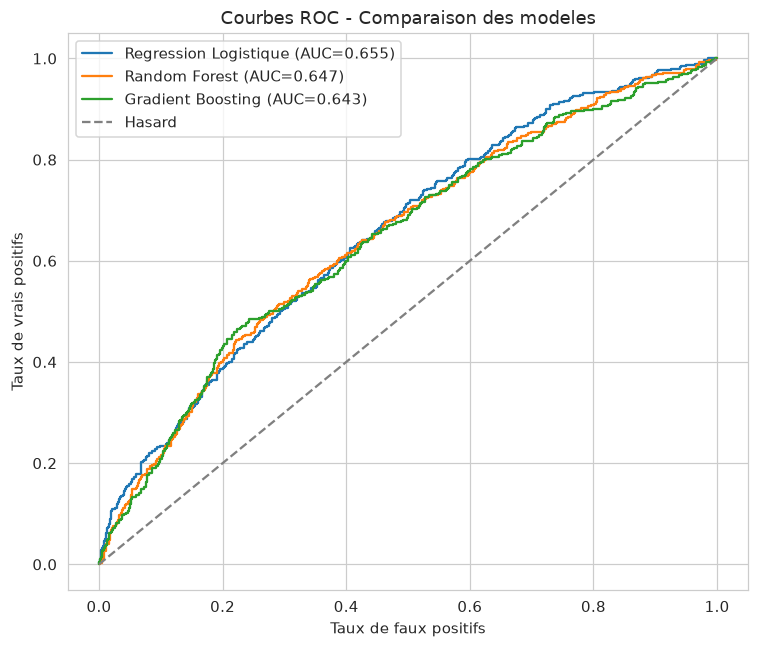

In [10]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - Comparaison des modeles")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_roc_curves.png", bbox_inches="tight")
plt.show()

## 5. Matrice de confusion du modèle retenu

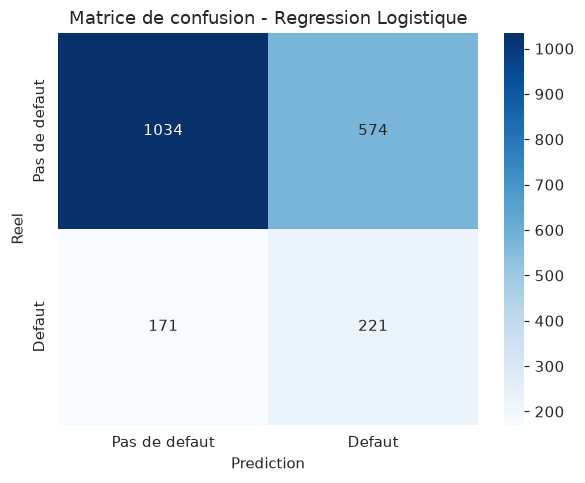

In [11]:
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pas de defaut", "Defaut"], yticklabels=["Pas de defaut", "Defaut"])
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title(f"Matrice de confusion - {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 6. Importance des variables

Quels facteurs pèsent le plus dans la décision du modèle ?

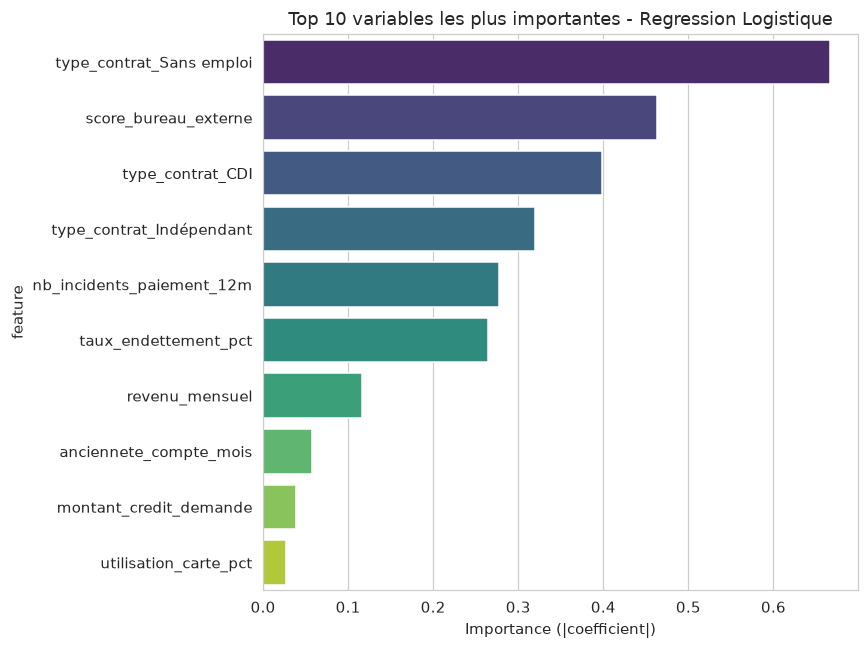

In [12]:
feature_names = (
    num_features
    + list(best_pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features))
)
model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    imp_label = "Importance"
else:
    importances = np.abs(model_step.coef_[0])
    imp_label = "Importance (|coefficient|)"

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title(f"Top 10 variables les plus importantes - {best_model_name}")
plt.xlabel(imp_label)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_feature_importance.png", bbox_inches="tight")
plt.show()

**Interprétation métier :** les variables les plus déterminantes sont le type de contrat (sans emploi notamment), le taux d'endettement, le score bureau externe et le nombre d'incidents de paiement passés — ce qui correspond aux facteurs de risque classiquement retenus dans les modèles de scoring crédit du secteur bancaire/fintech.


## 7. Export pour dashboard Power BI

On exporte les prédictions du modèle avec une segmentation en 3 niveaux de risque (Faible / Moyen / Élevé), directement exploitable pour construire un dashboard de pilotage à destination des équipes risque.


In [13]:
# ── Segmentation par tertiles des probabilités (calculés sur le train) ─────────
# Option retenue : segments relatifs (tertiles), seuils dérivés du jeu d'entraînement
# uniquement, aucune donnée test n'est utilisée pour les choisir.
# Avantage : résultats équilibrés et sans biais de look-ahead.
_proba_train = best_pipeline.predict_proba(X_train)[:, 1]
_t33 = float(np.percentile(_proba_train, 33.33))
_t67 = float(np.percentile(_proba_train, 66.67))

export_df = X_test.copy()
export_df["default_reel"]  = y_test.values
export_df["proba_defaut"]   = best_pipeline.predict_proba(X_test)[:, 1].round(4)
export_df["prediction"]     = y_pred_best
export_df["segment_risque"] = pd.cut(
    export_df["proba_defaut"],
    bins=[-np.inf, _t33, _t67, np.inf],
    labels=["Faible risque", "Risque moyen", "Risque eleve"]
)
export_df.to_csv(DATA_DIR / "export_powerbi_credit_scoring.csv", index=False)

print("Seuils de segmentation (tertiles, entraînement seulement) :")
print(f"  Faible risque : proba < {_t33:.4f}")
print(f"  Risque moyen  : {_t33:.4f} <= proba < {_t67:.4f}")
print(f"  Risque eleve  : proba >= {_t67:.4f}")
print("")
print(f"Distribution dans le jeu de test ({len(export_df)} clients) :")
print(export_df["segment_risque"].value_counts())
export_df.head()


Seuils de segmentation (tertiles, entraînement seulement) :
  Faible risque : proba < 0.3880
  Risque moyen  : 0.3880 <= proba < 0.5330
  Risque eleve  : proba >= 0.5330

Distribution dans le jeu de test (2000 clients) :
segment_risque
Faible risque    668
Risque moyen     666
Risque eleve     666
Name: count, dtype: int64


,age,revenu_mensuel,anciennete_compte_mois,nb_transactions_mois,montant_moyen_transaction,taux_endettement_pct,nb_incidents_paiement_12m,montant_credit_demande,type_contrat,score_bureau_externe,utilisation_carte_pct,default_reel,proba_defaut,prediction,segment_risque
374,55,1677.08,50,18,32.51,32.23,0,10908.14,CDI,794,35.36,0,0.2270,0,Faible risque
5791,18,2216.26,53,17,17.65,31.47,0,3038.89,CDI,691,68.32,0,0.3600,0,Faible risque
2579,52,1615.17,22,28,53.11,12.99,0,2028.65,Sans emploi,635,55.72,0,0.6193,1,Risque eleve
7206,37,2268.11,94,21,33.98,20.92,0,2555.57,CDI,517,65.76,0,0.5660,1,Risque eleve
605,53,3024.34,3,16,19.80,20.57,1,4486.85,Indépendant,774,19.09,1,0.2654,0,Faible risque


In [14]:
# ── Résumé final — toutes métriques calculées dynamiquement ──────────────────
_mask = ~results_df["Modele"].str.contains("Baseline", na=False)
_best = results_df[_mask].sort_values("AUC (test)", ascending=False).iloc[0]
_bl   = results_df[results_df["Modele"].str.contains("Baseline", na=False)].iloc[0]

print("=" * 62)
print("  RÉSUMÉ — Scoring de risque crédit (données synthétiques)")
print("=" * 62)
print(f"  Dataset          : {df.shape[0]} clients × {X.shape[1]} variables")
print(f"  Taux de défaut   : {df['default'].mean():.2%}")
print(f"  Split train/test : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"  Baseline AUC     : {_bl['AUC (test)']:.4f}  (hasard — 0 défaut détecté)")
print(f"  Meilleur modèle  : {_best['Modele']}")
print(f"  AUC (test)       : {_best['AUC (test)']:.4f}")
print(f"  AUC (cross-val)  : {_best['AUC (cross-val 5-fold)']:.4f}")
print(f"  F1-score         : {_best['F1-score']:.4f}")
print(f"  Gain vs baseline : +{_best['AUC (test)'] - _bl['AUC (test)']:.4f}")
print("=" * 62)


  RÉSUMÉ — Scoring de risque crédit (données synthétiques)
  Dataset          : 8000 clients × 11 variables
  Taux de défaut   : 19.62%
  Split train/test : 6000 / 2000
  Baseline AUC     : 0.5000  (hasard — 0 défaut détecté)
  Meilleur modèle  : Regression Logistique
  AUC (test)       : 0.6554
  AUC (cross-val)  : 0.6818
  F1-score         : 0.3724
  Gain vs baseline : +0.1554


## Conclusion

*(Les métriques exactes sont affichées dans le résumé ci-dessus.)*

- Les facteurs de risque identifiés sont cohérents avec les pratiques du secteur bancaire/fintech : stabilité de l'emploi, taux d'endettement, historique d'incidents, score de crédit externe.
- Les prédictions sont exportées et segmentées en 3 niveaux de risque (**Faible / Moyen / Élevé**), prêtes à alimenter un dashboard **Power BI** pour les équipes risque/crédit.
- **Note :** le jeu de données est synthétique, généré avec une logique métier réaliste (voir `scripts/01_generate_data.py`). Les résultats sont reproductibles avec `np.random.seed(42)`.

**Pistes d'amélioration :** données comportementales réelles, calibration du modèle (Platt scaling), XGBoost / LightGBM, seuil de décision ajusté au coût métier réel (faux négatif vs faux positif).
